In [25]:
from data_loader import hourly_data_loader
df = hourly_data_loader()

print(f'Available Features:')
print(df.columns.to_list())

Available Features:
['time', 'kwh', 'temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'hour', 'dayofweek', 'month', 'is_weekend', 'awake', 'evening', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'temp_avg_12', 'rhum_lag3', 'prcp_sum_12', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'wdir_sin', 'wdir_cos']


In [26]:
FEATURE_COLS = [
    'temp',
    'rhum', 
    'prcp', 
    'wspd', 
    'wdir_sin',
    'wdir_cos',
    'temp_lag1', 
    'temp_lag3', 
    'temp_lag6',
    'temp_avg_12',
    'rhum_lag3',
    'prcp_sum_12',
    'awake',
    'is_weekend',
    'evening',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos'
    ]

TARGET_COL   = "kwh"

In [27]:
from sklearn.preprocessing import StandardScaler

# Sequential separation to prevent data leakage
X_data = df[FEATURE_COLS].values
y_data = df[TARGET_COL].values.reshape(-1, 1)  # Reshape required for scaling

split_idx = int(len(X_data) * 0.75)

scaler_X = StandardScaler()
scaler_X.fit(X_data[:split_idx])          # Learn the math from the past
X_scaled = scaler_X.transform(X_data)     # Apply the math to the whole timeline

scaler_y = StandardScaler()
scaler_y.fit(y_data[:split_idx])
y_scaled = scaler_y.transform(y_data)

X_train = X_scaled[:split_idx]
X_test  = X_scaled[split_idx:]
y_train = y_scaled[:split_idx]
y_test  = y_scaled[split_idx:]

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}  (mean={y_train.mean():.3f} kWh, std={y_train.std():.3f})")
print(f"y_test  shape: {y_test.shape}  (mean={y_test.mean():.3f} kWh, std={y_test.std():.3f})")

Features:      ['temp', 'rhum', 'prcp', 'wspd', 'wdir_sin', 'wdir_cos', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'temp_avg_12', 'rhum_lag3', 'prcp_sum_12', 'awake', 'is_weekend', 'evening', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
X_train shape: (27637, 19)
X_test shape:  (9213, 19)
y_train shape: (27637, 1)  (mean=-0.000 kWh, std=1.000)
y_test  shape: (9213, 1)  (mean=0.240 kWh, std=1.084)


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_scaled = lr.predict(X_test)
pred_kwh = scaler_y.inverse_transform(pred_scaled)
test_kwh = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(test_kwh, pred_kwh))
r2   = r2_score(test_kwh, pred_kwh)
mae = mean_absolute_error(test_kwh, pred_kwh)

print(f"Linear Regression | R²={r2:.3f}  RMSE={rmse:.4f} kWh  MAE={mae:.4f} kWh")

# Coefficients
print(f'Coefficients:')
for i, coeff in enumerate(lr.coef_[0]):
    print(f'{FEATURE_COLS[i]}: {coeff:0.3f}')

Linear Regression | R²=0.384  RMSE=1.0975 kWh  MAE=0.8290 kWh
Coefficients:
temp: -0.577
rhum: -0.137
prcp: 0.011
wspd: -0.007
wdir_sin: 0.019
wdir_cos: -0.054
temp_lag1: 0.256
temp_lag3: 0.074
temp_lag6: 0.023
temp_avg_12: -0.345
rhum_lag3: 0.029
prcp_sum_12: 0.008
awake: 0.053
is_weekend: 0.026
evening: 0.150
hour_sin: 0.311
hour_cos: 0.085
month_sin: 0.000
month_cos: 0.056


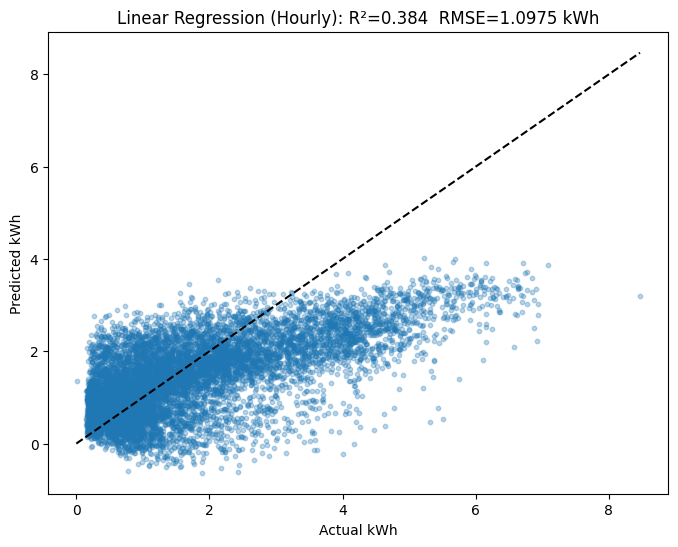

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(test_kwh, pred_kwh, alpha=0.3, s=10)
plt.plot([0, test_kwh.max()], [0, test_kwh.max()], 'k--')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.title(f'Linear Regression (Hourly): R²={r2:.3f}  RMSE={rmse:.4f} kWh')
plt.show()